# 🌞💨 Renewable Energy Forecasting — Phase 1: Data Collection
### Shell Internship Project

In this notebook we will:
1. Pull **solar** and **wind** energy data from the Renewables Ninja API
2. Pull supporting **weather data** from the Open-Meteo API
3. Clean and merge everything into two ready-to-model CSVs

**Location:** London, UK (lat: 51.5, lon: -0.12)  
**Date range:** 2019–2023 (5 years of data)

## 0. Install & Import Libraries

In [3]:
# Run this once to install dependencies
!pip install pandas numpy matplotlib requests prophet streamlit scikit-learn --quiet

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import os

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1. Configuration — Location & Date Range
Change these values if you want a different location or time period.

In [6]:
# --- Location ---
LAT = 51.5
LON = -0.12
LOCATION_NAME = 'London, UK'

# --- Date range ---
START_YEAR = 2019
END_YEAR   = 2023

# --- Renewables Ninja API token ---
# Sign up free at https://www.renewables.ninja/ → Profile → API token
NINJA_TOKEN = '19447628f22c3194ac250b7ae4be1c59f67f507f'  # <-- paste your token here

# --- Output directory ---
os.makedirs('data', exist_ok=True)

print(f'📍 Location : {LOCATION_NAME} ({LAT}, {LON})')
print(f'📅 Date range: {START_YEAR} – {END_YEAR}')

📍 Location : London, UK (51.5, -0.12)
📅 Date range: 2019 – 2023


## 2. Fetch Solar Data — Renewables Ninja

We model a **1 kWp rooftop solar panel** and pull hourly capacity factor (0–1).  
The API only allows 1 year per request, so we loop over each year.

In [8]:
def fetch_ninja_solar(lat, lon, year, token):
    """
    Fetch hourly solar capacity factor from Renewables Ninja for a given year.
    Returns a DataFrame with columns: [time, solar_cf]
    """
    url = 'https://www.renewables.ninja/api/data/pv'
    headers = {'Authorization': f'Token {token}'}
    params = {
        'lat'        : lat,
        'lon'        : lon,
        'date_from'  : f'{year}-01-01',
        'date_to'    : f'{year}-12-31',
        'dataset'    : 'merra2',
        'capacity'   : 1.0,      # 1 kWp system
        'system_loss': 0.1,      # 10% system losses
        'tracking'   : 0,        # fixed tilt
        'tilt'       : 35,       # degrees
        'azim'       : 180,      # south-facing
        'format'     : 'json'
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame.from_dict(data['data'], orient='index')
    df = df.rename(columns={'electricity': 'solar_cf'})
    # Keys are millisecond unix timestamps — convert accordingly
    df.index = pd.to_datetime(df.index.astype(float), unit='ms')
    df.index.name = 'time'
    return df


# --- Pull all years ---
solar_frames = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f'  Fetching solar {year}...', end=' ')
    df_year = fetch_ninja_solar(LAT, LON, year, NINJA_TOKEN)
    solar_frames.append(df_year)
    print(f'✅  {len(df_year)} rows')
    time.sleep(1)  # be polite to the API

solar_df = pd.concat(solar_frames)
print(f'\n📊 Total solar rows: {len(solar_df)}')
solar_df.head()

  Fetching solar 2019... ✅  8760 rows
  Fetching solar 2020... ✅  8784 rows
  Fetching solar 2021... ✅  8760 rows
  Fetching solar 2022... ✅  8760 rows
  Fetching solar 2023... ✅  8760 rows

📊 Total solar rows: 43824


,solar_cf
time,
2019-01-01 00:00:00,0.0000
2019-01-01 01:00:00,0.0000
2019-01-01 02:00:00,0.0000
2019-01-01 03:00:00,0.0000
2019-01-01 04:00:00,0.0000


## 3. Fetch Wind Data — Renewables Ninja

We model a **1 kW onshore wind turbine** at hub height 80m.

In [10]:
def fetch_ninja_wind(lat, lon, year, token):
    """
    Fetch hourly wind capacity factor from Renewables Ninja for a given year.
    Returns a DataFrame with columns: [time, wind_cf]
    """
    url = 'https://www.renewables.ninja/api/data/wind'
    headers = {'Authorization': f'Token {token}'}
    params = {
        'lat'       : lat,
        'lon'       : lon,
        'date_from' : f'{year}-01-01',
        'date_to'   : f'{year}-12-31',
        'dataset'   : 'merra2',
        'capacity'  : 1.0,
        'height'    : 80,        # hub height in metres
        'turbine'   : 'Vestas V80 2000',
        'format'    : 'json'
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    df = pd.DataFrame.from_dict(data['data'], orient='index')
    df = df.rename(columns={'electricity': 'wind_cf'})
    # Keys are millisecond unix timestamps — convert accordingly
    df.index = pd.to_datetime(df.index.astype(float), unit='ms')
    df.index.name = 'time'
    return df


# --- Pull all years ---
wind_frames = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f'  Fetching wind {year}...', end=' ')
    df_year = fetch_ninja_wind(LAT, LON, year, NINJA_TOKEN)
    wind_frames.append(df_year)
    print(f'✅  {len(df_year)} rows')
    time.sleep(1)

wind_df = pd.concat(wind_frames)
print(f'\n📊 Total wind rows: {len(wind_df)}')
wind_df.head()

  Fetching wind 2019... ✅  8760 rows
  Fetching wind 2020... ✅  8784 rows
  Fetching wind 2021... ✅  8760 rows
  Fetching wind 2022... ✅  8760 rows
  Fetching wind 2023... ✅  8760 rows

📊 Total wind rows: 43824


,wind_cf
time,
2019-01-01 00:00:00,0.2610
2019-01-01 01:00:00,0.2640
2019-01-01 02:00:00,0.2600
2019-01-01 03:00:00,0.2610
2019-01-01 04:00:00,0.2680


## 4. Fetch Weather Features — Open-Meteo

We pull supporting weather variables that will help the models:  
`temperature`, `cloud_cover`, `wind_speed_10m`, `wind_direction_10m`, `shortwave_radiation`

Open-Meteo is **completely free** — no API key needed.

In [12]:
def fetch_open_meteo(lat, lon, start_year, end_year):
    """
    Fetch hourly historical weather data from Open-Meteo Archive API.
    Returns a wide DataFrame indexed by time.
    """
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude'        : lat,
        'longitude'       : lon,
        'start_date'      : f'{start_year}-01-01',
        'end_date'        : f'{end_year}-12-31',
        'hourly'          : [
            'temperature_2m',
            'cloudcover',
            'windspeed_10m',
            'winddirection_10m',
            'shortwave_radiation'
        ],
        'timezone'        : 'Europe/London',
        'wind_speed_unit' : 'ms'
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    raw = response.json()

    df = pd.DataFrame(raw['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    df.columns = ['temp_c', 'cloud_cover_pct', 'wind_speed_ms', 'wind_dir_deg', 'radiation_wm2']
    return df


print('Fetching weather data (this covers all years in one request)...')
weather_df = fetch_open_meteo(LAT, LON, START_YEAR, END_YEAR)
print(f'✅ Weather rows: {len(weather_df)}')
weather_df.head()

Fetching weather data (this covers all years in one request)...
✅ Weather rows: 43824


,temp_c,cloud_cover_pct,wind_speed_ms,wind_dir_deg,radiation_wm2
time,,,,,
2019-01-01 00:00:00,6.8000,82,2.8600,258,0.0000
2019-01-01 01:00:00,7.0000,65,3.2600,259,0.0000
2019-01-01 02:00:00,6.6000,24,3.1800,257,0.0000
2019-01-01 03:00:00,5.7000,8,2.9300,262,0.0000
2019-01-01 04:00:00,5.0000,1,3.2200,263,0.0000


## 5. Merge & Clean

Join solar, wind and weather onto a single timeline. Then check for missing values.

In [14]:
# --- Fix timezones before merging ---
# Renewables Ninja returns naive UTC; Open-Meteo returns Europe/London tz-aware
# Strip timezone info so the index types match
solar_df.index   = solar_df.index.tz_localize(None)
wind_df.index    = wind_df.index.tz_localize(None)
weather_df.index = weather_df.index.tz_localize(None)

print('solar_df   rows:', len(solar_df))
print('wind_df    rows:', len(wind_df))
print('weather_df rows:', len(weather_df))

# --- Merge on shared time index ---
df = solar_df.join(wind_df, how='inner').join(weather_df, how='inner')

print('\nShape after merge:', df.shape)
print('\nMissing values per column:')
print(df.isnull().sum())

solar_df   rows: 43824
wind_df    rows: 43824
weather_df rows: 43824

Shape after merge: (43824, 7)

Missing values per column:
solar_cf           0
wind_cf            0
temp_c             0
cloud_cover_pct    0
wind_speed_ms      0
wind_dir_deg       0
radiation_wm2      0
dtype: int64


In [15]:
# --- Handle missing values ---
# Capacity factors: forward-fill short gaps (e.g. 1-2 hours), then drop remaining
df[['solar_cf', 'wind_cf']] = df[['solar_cf', 'wind_cf']].ffill(limit=2)

# Weather features: interpolate linearly
weather_cols = ['temp_c', 'cloud_cover_pct', 'wind_speed_ms', 'wind_dir_deg', 'radiation_wm2']
df[weather_cols] = df[weather_cols].interpolate(method='linear', limit=4)

# Drop any remaining NaN rows
df.dropna(inplace=True)

print('Shape after cleaning:', df.shape)
print('\nRemaining nulls:')
print(df.isnull().sum())

Shape after cleaning: (43824, 7)

Remaining nulls:
solar_cf           0
wind_cf            0
temp_c             0
cloud_cover_pct    0
wind_speed_ms      0
wind_dir_deg       0
radiation_wm2      0
dtype: int64


## 6. Feature Engineering

Add time-based features — these are simple but powerful for seasonal models.

In [17]:
df['hour']       = df.index.hour
df['day_of_week']= df.index.dayofweek       # 0 = Monday
df['month']      = df.index.month
df['day_of_year']= df.index.dayofyear
df['year']       = df.index.year

# Cyclical encoding — avoids the jump from Dec → Jan, 23:00 → 00:00
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

print('Features added. Final columns:')
print(list(df.columns))
df.head()

Features added. Final columns:
['solar_cf', 'wind_cf', 'temp_c', 'cloud_cover_pct', 'wind_speed_ms', 'wind_dir_deg', 'radiation_wm2', 'hour', 'day_of_week', 'month', 'day_of_year', 'year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


,solar_cf,wind_cf,temp_c,cloud_cover_pct,wind_speed_ms,wind_dir_deg,radiation_wm2,hour,day_of_week,month,day_of_year,year,hour_sin,hour_cos,month_sin,month_cos
time,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.0000,0.2610,6.8000,82,2.8600,258,0.0000,0,1,1,1,2019,0.0000,1.0000,0.5000,0.8660
2019-01-01 01:00:00,0.0000,0.2640,7.0000,65,3.2600,259,0.0000,1,1,1,1,2019,0.2588,0.9659,0.5000,0.8660
2019-01-01 02:00:00,0.0000,0.2600,6.6000,24,3.1800,257,0.0000,2,1,1,1,2019,0.5000,0.8660,0.5000,0.8660
2019-01-01 03:00:00,0.0000,0.2610,5.7000,8,2.9300,262,0.0000,3,1,1,1,2019,0.7071,0.7071,0.5000,0.8660
2019-01-01 04:00:00,0.0000,0.2680,5.0000,1,3.2200,263,0.0000,4,1,1,1,2019,0.8660,0.5000,0.5000,0.8660


## 7. Quick Sanity-Check Plots

Always visualise your data before modelling — catches issues early.

C:\Users\talha\AppData\Local\Temp\ipykernel_29912\4117066329.py:17: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\talha\AppData\Local\Temp\ipykernel_29912\4117066329.py:18: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('data/solar_wind_overview.png', dpi=150, bbox_inches='tight')
C:\Users\talha\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


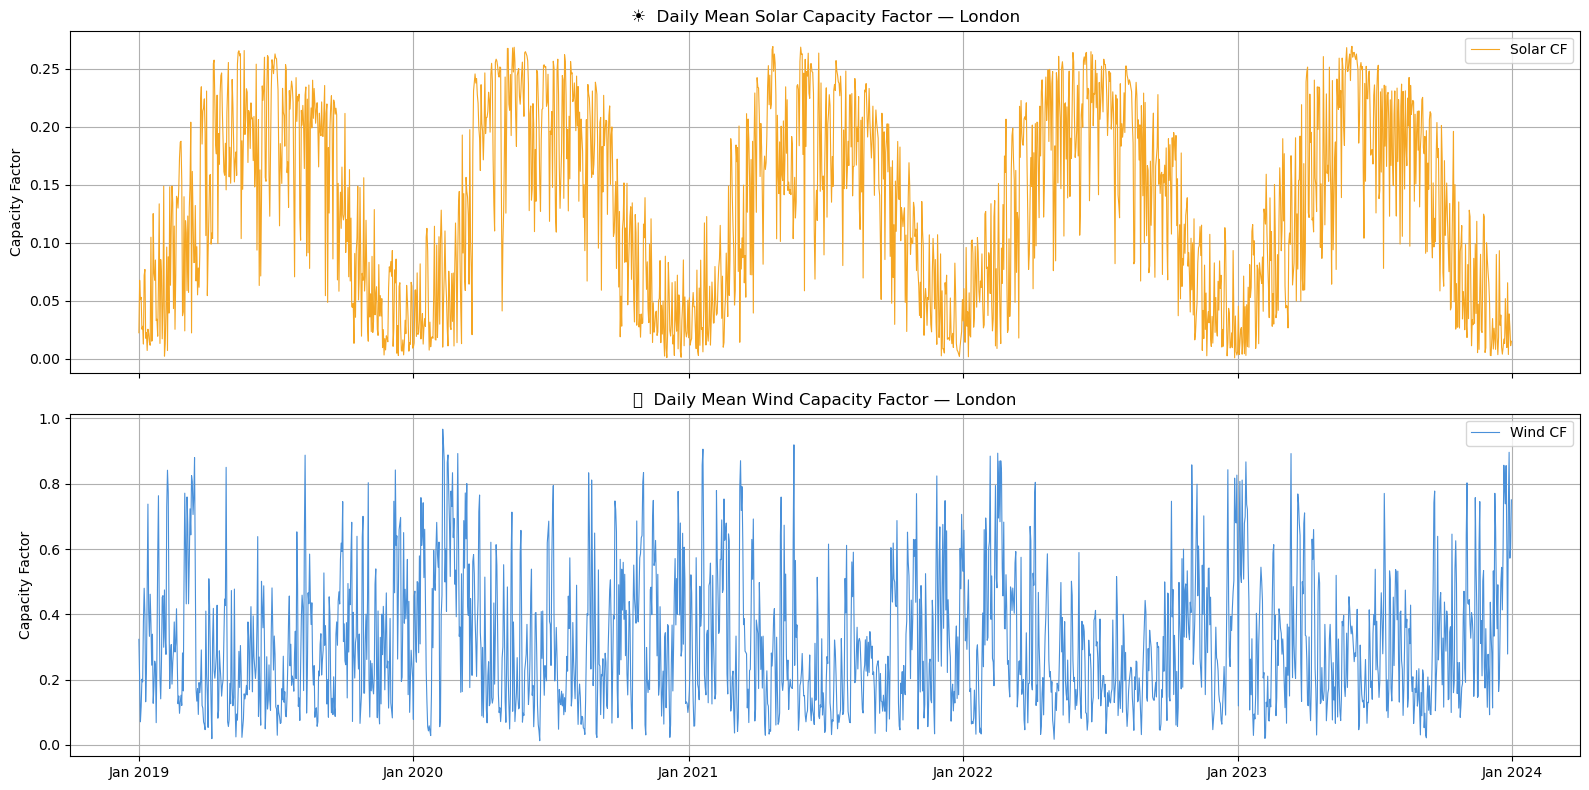

Plot saved to data/solar_wind_overview.png


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Resample to daily mean for a cleaner plot
daily = df[['solar_cf', 'wind_cf']].resample('D').mean()

axes[0].plot(daily.index, daily['solar_cf'], color='#f5a623', linewidth=0.8, label='Solar CF')
axes[0].set_ylabel('Capacity Factor')
axes[0].set_title('☀️  Daily Mean Solar Capacity Factor — London')
axes[0].legend()

axes[1].plot(daily.index, daily['wind_cf'], color='#4a90d9', linewidth=0.8, label='Wind CF')
axes[1].set_ylabel('Capacity Factor')
axes[1].set_title('💨  Daily Mean Wind Capacity Factor — London')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig('data/solar_wind_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to data/solar_wind_overview.png')

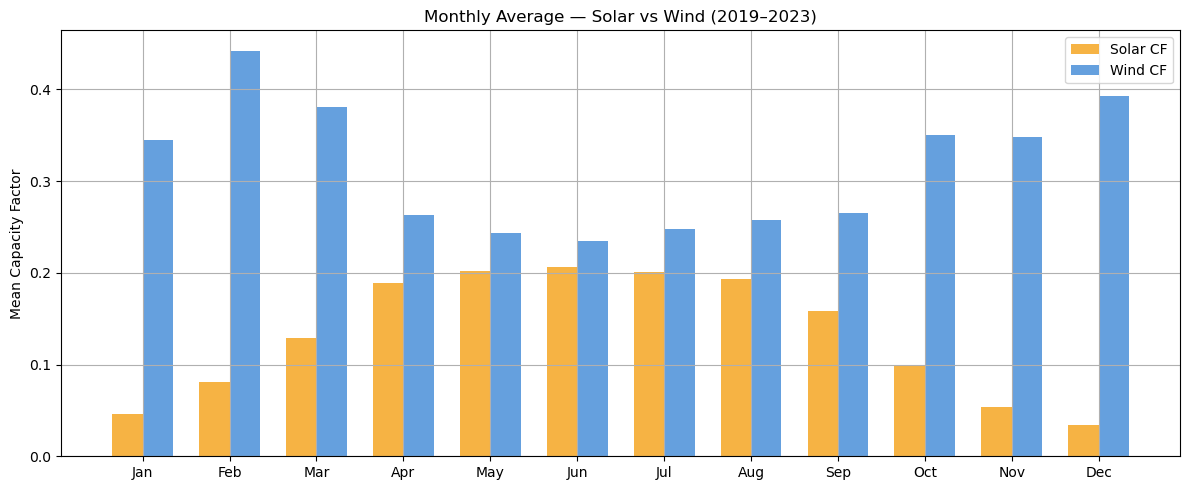

In [20]:
# --- Monthly averages: see seasonality clearly ---
# Derive month directly from index to avoid dependency on feature engineering cell
monthly = df.groupby(df.index.month)[['solar_cf', 'wind_cf']].mean()

# Ensure all 12 months present even if data has gaps
monthly = monthly.reindex(range(1, 13), fill_value=0)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(12)
width = 0.35

ax.bar(x - width/2, monthly['solar_cf'].values, width, label='Solar CF', color='#f5a623', alpha=0.85)
ax.bar(x + width/2, monthly['wind_cf'].values,  width, label='Wind CF',  color='#4a90d9', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Mean Capacity Factor')
ax.set_title('Monthly Average — Solar vs Wind (2019–2023)')
ax.legend()
plt.tight_layout()
plt.savefig('data/monthly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Clean Data

Save the merged, clean dataset to CSV — this is what Phase 2 & 3 will load.

In [22]:
output_path = 'data/energy_weather_london.csv'
df.to_csv(output_path)

print(f'✅ Data saved to {output_path}')
print(f'   Rows  : {len(df):,}')
print(f'   Cols  : {len(df.columns)}')
print(f'   Range : {df.index.min().date()} → {df.index.max().date()}')
df.describe()

✅ Data saved to data/energy_weather_london.csv
   Rows  : 43,824
   Cols  : 16
   Range : 2019-01-01 → 2023-12-31


,solar_cf,wind_cf,temp_c,cloud_cover_pct,wind_speed_ms,wind_dir_deg,radiation_wm2,hour,day_of_week,month,day_of_year,year,hour_sin,hour_cos,month_sin,month_cos
count,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000,43824.0000
mean,0.1329,0.3137,11.4152,66.4424,4.1334,192.2581,128.4168,11.5000,3.0016,6.5235,183.1002,2020.9995,-0.0000,-0.0000,-0.0049,-0.0021
std,0.2088,0.2336,6.2491,38.4828,2.1776,92.2909,196.7612,6.9223,1.9993,3.4486,105.4253,1.4140,0.7071,0.7071,0.7057,0.7085
min,0.0000,0.0010,-10.3000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,2019.0000,-1.0000,-1.0000,-1.0000,-1.0000
25%,0.0000,0.1310,7.1000,29.0000,2.4300,109.0000,0.0000,5.7500,1.0000,4.0000,92.0000,2020.0000,-0.7071,-0.7071,-0.8660,-0.8660
50%,0.0000,0.2640,11.1000,89.0000,3.7200,218.0000,6.0000,11.5000,3.0000,7.0000,183.0000,2021.0000,0.0000,-0.0000,-0.0000,-0.0000
75%,0.2060,0.4360,15.8000,100.0000,5.4400,254.0000,201.0000,17.2500,5.0000,10.0000,274.0000,2022.0000,0.7071,0.7071,0.5000,0.8660
max,0.7970,0.9870,37.9000,100.0000,18.8800,360.0000,881.0000,23.0000,6.0000,12.0000,366.0000,2023.0000,1.0000,1.0000,1.0000,1.0000


---
## ✅ Phase 1 Complete!

You now have a clean `energy_weather_london.csv` with:
- Hourly solar & wind capacity factors (2019–2023)
- Supporting weather features
- Time-based & cyclical features

**Next up → Phase 2: Exploratory Data Analysis**  
We'll dig into seasonality, correlations, and spot any outliers before modelling.